# AIR QUALITY PREDICTION USING LINEAR REGRESSION

- https://en.tutiempo.net/climate  Using this website builded the Webscrapping with the library of beautyfulsoup


In this Project Scrapping the data from the website and after taken data we calcluated the daily hours Air Qulaity data into daily average data of 2013 to 2017  for target value of PM2.5 after we Predicting the Air Quality using Linear Regression  

Columns
- T	Average annual temperature
- TM	Annual average maximum temperature
- Tm	Average annual minimum temperature
- PP	Rain or snow precipitation total annual
- V	Annual average wind speed
- RA	Number of days with rain
- SN	Number of days with snow
- TS	Number of days with storm
- FG	Number of foggy days
- TN	Number of days with tornado
- GR	Number of days with hail

# Applying  Linear Regression Model

              Country              City  AQI Value AQI Category  CO AQI Value  \
0  Russian Federation        Praskoveya         51     Moderate             1   
1              Brazil  Presidente Dutra         41         Good             1   
2              Brazil  Presidente Dutra         41         Good             1   
3               Italy   Priolo Gargallo         66     Moderate             1   
4              Poland         Przasnysz         34         Good             1   

  CO AQI Category  Ozone AQI Value Ozone AQI Category  NO2 AQI Value  \
0            Good               36               Good              0   
1            Good                5               Good              1   
2            Good                5               Good              1   
3            Good               39               Good              2   
4            Good               34               Good              0   

  NO2 AQI Category  PM2.5 AQI Value PM2.5 AQI Category      lat      lng  
0    

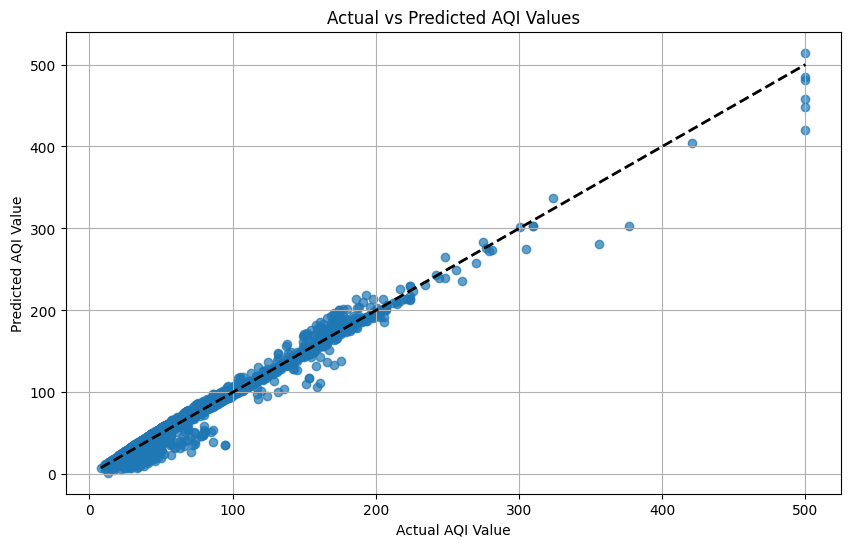

RuntimeError: `lowess=True` requires statsmodels, an optional dependency, to be installed.

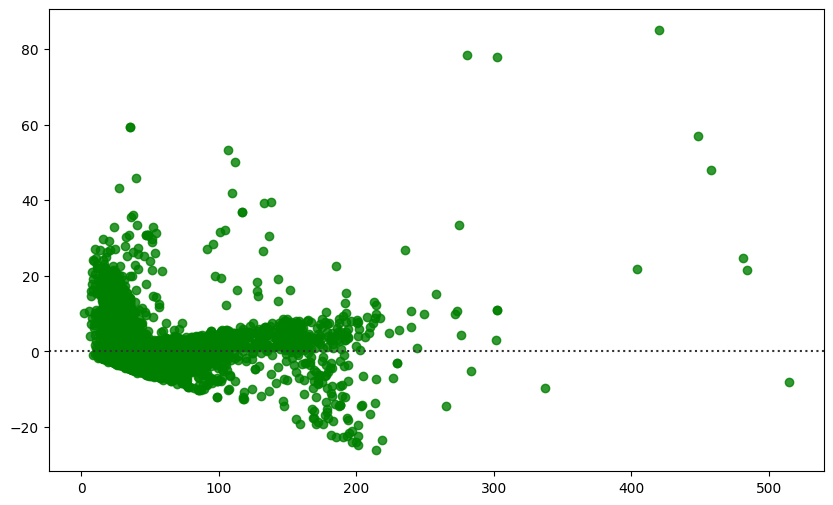

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load dataset
data = pd.read_csv('Data\Real-Data\AQI and Lat Long of Countries.csv')

# Display the first few rows of the dataset
print(data.head())

# Select features (X) and target (Y)
# Assuming we want to predict 'AQI Value' based on other features
X = data[['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']]
Y = data['AQI Value']  # This should be numeric

# Convert categorical columns if necessary (e.g., 'AQI Category')
# If you need to encode categorical variables, do so here
# For example, if you want to drop non-numeric columns:
data.drop(columns=['Country', 'City', 'AQI Category'], inplace=True)

# Ensure that all features in X are numeric
X = X.apply(pd.to_numeric, errors='coerce')  # Convert to numeric, forcing errors to NaN
Y = pd.to_numeric(Y, errors='coerce')  # Convert target variable to numeric

# Drop any rows with NaN values created during conversion
X.dropna(inplace=True)
Y = Y[X.index]  # Align Y with X after dropping NaN rows

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# Scale the features (important for some algorithms)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize and fit the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate the model using relevant metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:.4f}')
print(f'R^2 Score: {r2:.4f}')

# Visualization of Actual vs Predicted Values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)  # Diagonal line
plt.xlabel('Actual AQI Value')
plt.ylabel('Predicted AQI Value')
plt.title('Actual vs Predicted AQI Values')
plt.grid()
plt.show()

# Residual Plot
plt.figure(figsize=(10, 6))
sns.residplot(x=y_pred, y=y_test - y_pred, lowess=True, color="g", 
               line_kws={"color": "red", "lw": 1})
plt.xlabel('Predicted AQI Value')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.axhline(0, linestyle='--', color='red')
plt.show()

It looks like Right Skwed Distribution 

## Train Test Split

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test , Y_train, Y_test = train_test_split(X,Y, test_size=0.3,random_state=0)

In [6]:
from sklearn.linear_model import LinearRegression

In [7]:
Regressor = LinearRegression()

In [8]:
Regressor.fit(X_train,Y_train)

LinearRegression()

In [9]:
Regressor.coef_

array([0.33129197, 0.1992545 , 0.03824852, 0.94415377])

In [10]:
Regressor.intercept_

np.float64(-0.4260079006852848)

Lets find the R Squared value for train data

In [11]:
print("Coefficient of determination R^2 <-- on train set: {}".format(Regressor.score(X_train, Y_train)))

Coefficient of determination R^2 <-- on train set: 0.9729697159796591


R square Value of train data is near to 1 so its prety much good

Lets find the R Squared Value for Test Data

In [12]:
print("Coefficient of determination R^2 <-- on train set: {}".format(Regressor.score(X_test, Y_test)))

Coefficient of determination R^2 <-- on train set: 0.9693962061780651


R square Value of test data is also near to 1 so its prety much good

Lets check cross validation score

In [13]:
from sklearn.model_selection import cross_val_score
score=cross_val_score(Regressor,X,Y,cv=5)

In [14]:
score.mean()

np.float64(0.9713691872125594)

## Model Evalaution

In [15]:
coeff_df = pd.DataFrame(Regressor.coef_,X.columns,columns=['Coefficient'])

In [16]:
coeff_df

,Coefficient
CO AQI Value,0.331292
Ozone AQI Value,0.199255
NO2 AQI Value,0.038249
PM2.5 AQI Value,0.944154


Interpreting the coefficients:

- Holding all other features fixed, a 1 unit increase in T is associated with an *increase of 2.639490 in AQI PM2.5 *.
- Holding all other features fixed, a 1 unit increase in TM is associated with an *increase of 0.519979 in AQI PM 2.5 *.
- Holding all other features fixed, a 1 unit increase in Tm is associated with an *decrease of -7.598118 in AQI PM 2.5 *.
- Holding all other features fixed, a 1 unit increase in SLP is associated with an *increase of 0.493220 in AQI PM2.5 *.
- Holding all other features fixed, a 1 unit increase in H is associated with an *increase of -0.837064 in AQI PM 2.5 *.
- Holding all other features fixed, a 1 unit increase in VV is associated with an *decrease of -50.430135 in AQI PM 2.5 *.
- Holding all other features fixed, a 1 unit increase in V is associated with an *decrease of -2.754178 in AQI PM 2.5 *.
- Holding all other features fixed, a 1 unit increase in VM is associated with an *decrease of -0.039266 in AQI PM 2.5 *.






Lets predict the test data

In [17]:
prediction = Regressor.predict(X_test)

C:\Users\Hitarth\AppData\Local\Temp\ipykernel_3432\1717588963.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Y_test - prediction)


<Axes: xlabel='AQI Value', ylabel='Density'>

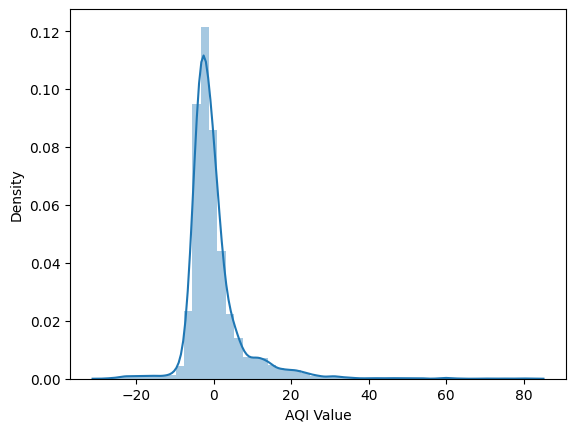

In [18]:
sns.distplot(Y_test - prediction)

The test data has Gaussian Distributiion it so good to help to predict the data

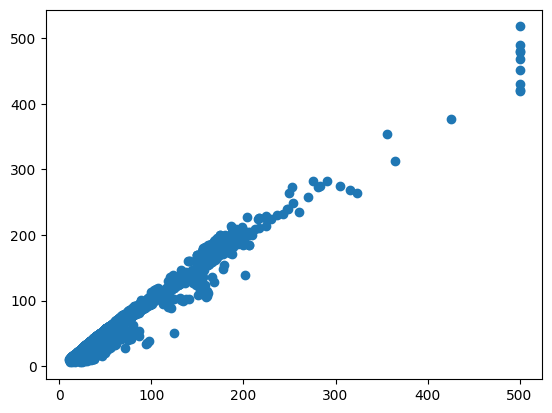

In [19]:
plt.scatter(Y_test,prediction)

Scatter visualization also shows the its good for test data 

# Regression Evaluation Metrics


Here are three common evaluation metrics for regression problems:

**Mean Absolute Error** (MAE) is the mean of the absolute value of the errors:

$$\frac 1n\sum_{i=1}^n|y_i-\hat{y}_i|$$

**Mean Squared Error** (MSE) is the mean of the squared errors:

$$\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2$$

**Root Mean Squared Error** (RMSE) is the square root of the mean of the squared errors:

$$\sqrt{\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2}$$

Comparing these metrics:

- **MAE** is the easiest to understand, because it's the average error.
- **MSE** is more popular than MAE, because MSE "punishes" larger errors, which tends to be useful in the real world.
- **RMSE** is even more popular than MSE, because RMSE is interpretable in the "y" units.

All of these are **loss functions**, because we want to minimize them.

In [20]:
from sklearn import metrics

In [21]:
print('MAE:', metrics.mean_absolute_error(Y_test, prediction))
print('MSE:', metrics.mean_squared_error(Y_test, prediction))
print('RMSE:', np.sqrt(metrics.mean_squared_error(Y_test, prediction)))

MAE: 4.497559899760738
MSE: 56.18031037319792
RMSE: 7.495352584982105


For the deploymenent process save the file using pickle package